# Experiment 2 — Cross-Dataset Generalisation
## Models trained on Data_Raw_6class_All → tested on Dataset V2 (different hospital)

| | |
|---|---|
| **Goal** | Test whether models trained on primary dataset generalise to an independent dataset from a different clinical setting |
| **Train source** | Data_Raw_6class_All (Hospital de Clínicas, 411 images, 3-class) |
| **Test source** | Dataset V2 / classification (independent hospital, 160 images, binary) |
| **Evaluation** | Binary: Healthy (0) vs Diseased (Active+Inactive→1) |
| **Models** | All 6 from Experiment 1, evaluated at every label fraction |
| **Key question** | Does domain-specific SSL (RETFound-DINOv2) generalise better than supervised CNNs? |

### Why binary evaluation
Dataset V2 contains only `healthy` and `non_healthy` folders — no Active/Inactive split.
Models predict 3 classes; we collapse: Active (1) + Inactive (2) → Diseased (1), Healthy (0) → Healthy (0).
This mirrors real clinical triage: *does this patient have ocular toxoplasmosis?*

---

## Cell 1 — Imports & Setup

In [1]:
# ── This notebook requires Experiment 1 to have been run first ────────────────
# It loads the trained models saved during E1 and re-evaluates on Dataset V2
# with proper binary metrics.

import os, random, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models
import timm

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

Device  : cuda
GPU     : Tesla T4


## Cell 2 — Dataset Paths & Config

In [2]:
DS1_ROOT     = Path('/kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset')
DS2_ROOT     = Path('/kaggle/input/datasets/sakibapon/ocular-toxoplasmosis')
DIR_6CLASS   = DS1_ROOT / 'Data_Raw_6class_All' / 'Data_Raw_6class_All'
DIR_V2_CLASS = DS2_ROOT / 'Dataset V2' / 'classification'
DIR_BINARY   = DS2_ROOT / 'BinaryClassification'
RETFOUND_CKPT = Path('/kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth')

EXTS         = {'.jpg','.jpeg','.png','.bmp','.tiff'}
LABEL_FRACS  = [0.05, 0.10, 0.25, 0.50, 1.00]
EPOCHS       = 30
PHASE1_EP    = 10
BATCH_SIZE   = 16
IMG_SIZE     = 224
LR           = 3e-4
WEIGHT_DECAY = 0.05
PATIENCE     = 7

CLASS_NAMES_3  = ['Healthy', 'Active', 'Inactive']   # 3-class (training)
CLASS_NAMES_2  = ['Healthy', 'Diseased']              # binary (E2 evaluation)
NUM_CLASSES    = 3
PALETTE_3      = ['#4CAF50','#E53935','#1E88E5']
PALETTE_2      = ['#4CAF50','#E53935']

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(15),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
val_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(), T.Normalize(MEAN, STD),
])

print('Config ready.')
print(f'Primary (train) : {DIR_6CLASS}  exists={DIR_6CLASS.exists()}')
print(f'Dataset V2      : {DIR_V2_CLASS}  exists={DIR_V2_CLASS.exists()}')
print(f'Binary dataset  : {DIR_BINARY}  exists={DIR_BINARY.exists()}')

Config ready.
Primary (train) : /kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset/Data_Raw_6class_All/Data_Raw_6class_All  exists=True
Dataset V2      : /kaggle/input/datasets/sakibapon/ocular-toxoplasmosis/Dataset V2/classification  exists=True
Binary dataset  : /kaggle/input/datasets/sakibapon/ocular-toxoplasmosis/BinaryClassification  exists=True


## Cell 3 — Build DataFrames

In [3]:
FOLDER_TO_LABEL = {
    'healthy':0, 'active':1, 'active_active':1,
    'inactive':2, 'inactive_inactive':2, 'active_inactive':2,
}

def build_primary_df():
    rows=[]
    for folder,label in FOLDER_TO_LABEL.items():
        d=DIR_6CLASS/folder
        if not d.exists(): continue
        imgs=[f for f in d.iterdir() if f.suffix.lower() in EXTS]
        print(f'  {folder:25s}: {len(imgs):4d} → {CLASS_NAMES_3[label]}')
        for p in imgs: rows.append({'path':str(p),'label':label,'src':folder})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

def build_v2_df(binary=True):
    """
    Dataset V2: healthy / non_healthy (binary).
    binary=True  → label 0=Healthy, 1=Diseased
    binary=False → label 0=Healthy, 2=Inactive (best proxy for non_healthy)
    """
    rows=[]
    v2_map={'healthy':0,'health':0,'non_healthy':1,'inactive':1,'diseased':1,'active':1}
    for sp in sorted(DIR_V2_CLASS.iterdir()):
        if not sp.is_dir(): continue
        for cd in sorted(sp.iterdir()):
            if not cd.is_dir(): continue
            label=v2_map.get(cd.name.lower())
            if label is None: print(f'  [WARN] Unknown: {cd.name}'); continue
            imgs=[f for f in cd.iterdir() if f.suffix.lower() in EXTS]
            print(f'  {sp.name}/{cd.name:15s} → {CLASS_NAMES_2[label]} ({len(imgs)})')
            for p in imgs: rows.append({'path':str(p),'label_bin':label,'src':cd.name})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

def build_binary_ds1_df():
    """Data_Processed_Paper: Diseased/Healthy — for binary baseline comparison."""    
    rows=[]
    pp=DS1_ROOT/'Data_Processed_Paper'/'Data_Processed_Paper'
    if not pp.exists(): return pd.DataFrame()
    for cd in sorted(pp.iterdir()):
        if not cd.is_dir(): continue
        label=0 if cd.name.lower()=='healthy' else 1
        imgs=[f for f in cd.iterdir() if f.suffix.lower() in EXTS]
        print(f'  DS1 Binary/{cd.name:15s}: {len(imgs)} → {CLASS_NAMES_2[label]}')
        for p in imgs: rows.append({'path':str(p),'label_bin':label,'src':cd.name})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

print('Building primary (3-class) dataset:')
primary_df = build_primary_df()
print(f'\nPrimary total: {len(primary_df)}')

print('\nBuilding Dataset V2 (binary external test):')
v2_df = build_v2_df()
print(f'V2 total: {len(v2_df)}  |  H={( v2_df["label_bin"]==0 ).sum()}  D={( v2_df["label_bin"]==1 ).sum()}')

Building primary (3-class) dataset:
  healthy                  :  132 → Healthy
  active                   :   33 → Active
  active_active            :    1 → Active
  inactive                 :  187 → Inactive
  inactive_inactive        :    1 → Inactive
  active_inactive          :   57 → Inactive

Primary total: 411

Building Dataset V2 (binary external test):
  train/healthy         → Healthy (64)
  train/non_healthy     → Diseased (64)
  val/healthy         → Healthy (16)
  val/non_healthy     → Diseased (16)
V2 total: 160  |  H=80  D=80


## Cell 4 — Primary Train/Val/Test Splits

In [4]:
# ── 3-class splits from primary dataset (same as E1) ──────────────────────────
train_df, temp_df = train_test_split(primary_df, test_size=0.40,
                                      stratify=primary_df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50,
                                      stratify=temp_df['label'], random_state=SEED)
train_df=train_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)

print(f'Primary splits: Train={len(train_df)}  Val={len(val_df)}  Test={len(test_df)}')
print(f'V2 external   : {len(v2_df)} images (all used as test)')

# ── Dataset V2: split into val (20%) and test (80%) for unbiased evaluation ──
v2_val_df, v2_test_df = train_test_split(v2_df, test_size=0.80,
                                           stratify=v2_df['label_bin'], random_state=SEED)
print(f'V2 val: {len(v2_val_df)}  V2 test: {len(v2_test_df)}')
print('(V2 val used for cross-val early stopping; V2 test is held-out)')

Primary splits: Train=246  Val=82  Test=83
V2 external   : 160 images (all used as test)
V2 val: 32  V2 test: 128
(V2 val used for cross-val early stopping; V2 test is held-out)


## Cell 5 — Dataset Classes

In [5]:
class OTDataset3(Dataset):
    """Primary 3-class dataset."""    
    def __init__(self, df, transform=None):
        self.df=df.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, int(row['label'])

class OTDatasetBin(Dataset):
    """Dataset V2 binary dataset (label_bin: 0=Healthy, 1=Diseased)."""    
    def __init__(self, df, transform=None):
        self.df=df.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, int(row['label_bin'])

# ── Fixed loaders ──────────────────────────────────────────────────────────────
val_loader    = DataLoader(OTDataset3(val_df,  val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader   = DataLoader(OTDataset3(test_df, val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
v2_val_loader = DataLoader(OTDatasetBin(v2_val_df,  val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
v2_test_loader= DataLoader(OTDatasetBin(v2_test_df, val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

print('All loaders ready.')
print(f'  Primary val   : {len(val_loader)} batches')
print(f'  Primary test  : {len(test_loader)} batches')
print(f'  V2 val        : {len(v2_val_loader)} batches')
print(f'  V2 test       : {len(v2_test_loader)} batches')

All loaders ready.
  Primary val   : 6 batches
  Primary test  : 6 batches
  V2 val        : 2 batches
  V2 test       : 8 batches


## Cell 6 — Model Builders (same as E1)

In [6]:
import copy
print('Pre-loading DINOv2 architecture...')
_DINO_ARCH = torch.hub.load('facebookresearch/dinov2','dinov2_vitl14',
                              pretrained=False, trust_repo=True)
print(f'DINOv2 arch cached | embed_dim={_DINO_ARCH.embed_dim}')

def build_retfound_dinov2(num_classes):
    import numpy as np
    torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    try:    ckpt=torch.load(RETFOUND_CKPT,map_location='cpu',weights_only=True)
    except: ckpt=torch.load(RETFOUND_CKPT,map_location='cpu',weights_only=False)
    state=ckpt['model_state_dict']
    pe=state['pos_embed']; cls_tok=pe[:,:1,:]
    patch_pe=pe[:,1:,:].reshape(1,36,36,1024).permute(0,3,1,2)
    patch_pe=torch.nn.functional.interpolate(patch_pe,size=(37,37),mode='bicubic',align_corners=False)
    patch_pe=patch_pe.permute(0,2,3,1).reshape(1,1369,1024)
    state['pos_embed']=torch.cat([cls_tok,patch_pe],dim=1)
    state={k:v for k,v in state.items() if not k.startswith('head') and not k.startswith('fc')}
    backbone=copy.deepcopy(_DINO_ARCH)
    backbone.load_state_dict(state,strict=False)
    class RETFoundDINOv2(nn.Module):
        def __init__(self,bb,nc):
            super().__init__(); self.bb=bb; self.head=nn.Linear(bb.embed_dim,nc)
            self.frozen=True; self._freeze_backbone()
        def _freeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad=False; self.frozen=True
        def _unfreeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad=True; self.frozen=False
        def forward(self,x):
            out=self.bb.forward_features(x)
            cls=out['x_norm_clstoken'] if isinstance(out,dict) else out[:,0]
            return self.head(cls)
    return RETFoundDINOv2(backbone,num_classes)

def build_dinov2(num_classes):
    backbone=torch.hub.load('facebookresearch/dinov2','dinov2_vitl14',pretrained=True,trust_repo=True)
    class DINOv2Clf(nn.Module):
        def __init__(self,bb,nc):
            super().__init__(); self.bb=bb; self.head=nn.Linear(bb.embed_dim,nc)
        def forward(self,x):
            out=self.bb.forward_features(x)
            cls=out['x_norm_clstoken'] if isinstance(out,dict) else out[:,0]
            return self.head(cls)
    return DINOv2Clf(backbone,num_classes)

def build_resnet50(nc):
    m=tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc=nn.Linear(m.fc.in_features,nc); return m

def build_vitb16(nc):
    m=tv_models.vit_b_16(weights=tv_models.ViT_B_16_Weights.IMAGENET1K_V1)
    m.heads.head=nn.Linear(m.heads.head.in_features,nc); return m

def build_efficientnetv2s(nc):
    m=tv_models.efficientnet_v2_s(weights=tv_models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    m.classifier[1]=nn.Linear(m.classifier[1].in_features,nc); return m

def build_convnext_base(nc):
    m=tv_models.convnext_base(weights=tv_models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    m.classifier[2]=nn.Linear(m.classifier[2].in_features,nc); return m

MODEL_REGISTRY={
    'RETFound-DINOv2' :build_retfound_dinov2,
    'DINOv2-Large'    :build_dinov2,
    'ResNet-50'       :build_resnet50,
    'ViT-B/16'        :build_vitb16,
    'EfficientNetV2-S':build_efficientnetv2s,
    'ConvNeXt-Base'   :build_convnext_base,
}
print('Model registry ready:', list(MODEL_REGISTRY.keys()))

Pre-loading DINOv2 architecture...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
DINOv2 arch cached | embed_dim=1024
Model registry ready: ['RETFound-DINOv2', 'DINOv2-Large', 'ResNet-50', 'ViT-B/16', 'EfficientNetV2-S', 'ConvNeXt-Base']


## Cell 7 — Training & Evaluation Helpers

In [7]:
def get_class_weights(sdf, label_col='label'):
    counts=np.array([(sdf[label_col]==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    return torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE)

def train_one_epoch(model,loader,criterion,optimizer,scaler):
    model.train(); total_loss=correct=total=0
    for imgs,labels in loader:
        imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out=model(imgs); loss=criterion(out,labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss+=loss.item()*len(labels)
        correct+=(out.argmax(1)==labels).sum().item(); total+=len(labels)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate_3class(model, loader):
    """Standard 3-class evaluation."""    
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs=torch.softmax(logits,1).numpy(); preds=logits.argmax(1).numpy()
    acc=accuracy_score(labels,preds)
    f1=f1_score(labels,preds,average='macro',zero_division=0)
    try: auc=roc_auc_score(labels,probs,multi_class='ovr',average='macro')
    except: auc=float('nan')
    return acc,f1,auc,preds,labels,probs

@torch.no_grad()
def evaluate_binary_from_3class(model, loader):
    """
    Evaluate model (trained on 3 classes) on binary external dataset.
    Collapses 3-class output → binary:
      Healthy (0) → 0
      Active  (1) + Inactive (2) → 1 (Diseased)
    Disease probability = P(Active) + P(Inactive) = 1 - P(Healthy)
    """
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs_3=torch.softmax(logits,1).numpy()

    # Binary disease probability = 1 - P(Healthy)
    disease_prob = 1.0 - probs_3[:,0]           # P(Diseased)
    healthy_prob = probs_3[:,0]                  # P(Healthy)
    bin_probs    = np.stack([healthy_prob, disease_prob], axis=1)  # [N,2]

    # Threshold at 0.5: predict Diseased if P(Diseased) > 0.5
    bin_preds = (disease_prob > 0.5).astype(int)

    acc  = accuracy_score(labels, bin_preds)
    f1   = f1_score(labels, bin_preds, average='macro', zero_division=0)
    sens = f1_score(labels, bin_preds, pos_label=1, average='binary', zero_division=0)  # recall for diseased
    spec_preds = 1 - bin_preds
    spec = f1_score(1-labels, spec_preds, pos_label=1, average='binary', zero_division=0)
    try:   auc = roc_auc_score(labels, disease_prob)
    except: auc = float('nan')
    try:   ap  = average_precision_score(labels, disease_prob)
    except: ap  = float('nan')
    return acc, f1, auc, ap, sens, spec, bin_preds, labels, bin_probs

def get_llrd_optimizer(model, base_lr=1e-5, head_lr=1e-3, decay=0.65, wd=0.05):
    param_groups=[{'params':list(model.head.parameters()),'lr':head_lr,'name':'head'}]
    param_groups.append({'params':list(model.bb.norm.parameters()),'lr':base_lr*(decay**0),'name':'norm'})
    num_blocks=len(model.bb.blocks)
    for i,block in enumerate(reversed(model.bb.blocks)):
        param_groups.append({'params':list(block.parameters()),'lr':base_lr*(decay**(i+1)),'name':f'block_{num_blocks-1-i}'})
    other=[p for p in (list(model.bb.patch_embed.parameters())+
                        [model.bb.cls_token,model.bb.pos_embed]) if p.requires_grad]
    if other: param_groups.append({'params':other,'lr':base_lr*(decay**(num_blocks+1)),'name':'embed'})
    return optim.AdamW(param_groups,weight_decay=wd)

def train_model(model_name, subset_df):
    """Train on 3-class primary data (identical to E1)."""    
    set_seed(SEED)
    model=MODEL_REGISTRY[model_name](NUM_CLASSES).to(DEVICE)
    train_ds=OTDataset3(subset_df,train_tfm)
    train_ld=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,
                         num_workers=2,pin_memory=True,
                         drop_last=len(train_ds)>=BATCH_SIZE)
    weights=get_class_weights(subset_df)
    criterion=nn.CrossEntropyLoss(weight=weights)
    scaler=torch.cuda.amp.GradScaler()
    is_rf=hasattr(model,'frozen')

    if is_rf:
        print(f'  [P1] Frozen backbone ({PHASE1_EP} epochs)')
        opt1=optim.AdamW(model.head.parameters(),lr=1e-3,weight_decay=WEIGHT_DECAY)
        sch1=optim.lr_scheduler.CosineAnnealingLR(opt1,T_max=PHASE1_EP)
        for epoch in range(1,PHASE1_EP+1):
            tr_loss,_=train_one_epoch(model,train_ld,criterion,opt1,scaler)
            _,_,val_auc,*_=evaluate_3class(model,val_loader)
            sch1.step()
            if epoch%5==0 or epoch==1:
                print(f'    [P1] E{epoch:02d} | loss={tr_loss:.4f} | val_auc={val_auc:.3f}')

    if is_rf:
        model._unfreeze_backbone()
        optimizer=get_llrd_optimizer(model,base_lr=1e-5,head_lr=1e-3,decay=0.65)
        ep_offset=PHASE1_EP
        print(f'  [P2] LLRD fine-tune ({EPOCHS} epochs)')
    else:
        optimizer=optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
        ep_offset=0

    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
    best_auc=0.0; best_state=None; wait=0

    for epoch in range(1,EPOCHS+1):
        tr_loss,tr_acc=train_one_epoch(model,train_ld,criterion,optimizer,scaler)
        val_acc,val_f1,val_auc,*_=evaluate_3class(model,val_loader)
        scheduler.step()
        if val_auc>best_auc:
            best_auc=val_auc; best_state=deepcopy(model.state_dict()); wait=0
        else:
            wait+=1
            if wait>=PATIENCE:
                print(f'    Early stop @ epoch {epoch+ep_offset}  best_val_auc={best_auc:.4f}')
                break
        phase='P2' if is_rf else 'P1'
        if epoch%5==0 or epoch==1:
            print(f'    [{phase}] E{epoch+ep_offset:02d} | loss={tr_loss:.4f} | '
                  f'val_auc={val_auc:.3f} | val_f1={val_f1:.3f}')

    model.load_state_dict(best_state)
    return model

print('Helpers defined.')

Helpers defined.


## Cell 8 — Run Experiment 2

For each model × label fraction:
1. Train on primary 3-class data (identical setup to E1)
2. Evaluate on internal 3-class test set (same as E1 — for reference)
3. Evaluate on V2 test set using binary collapse (primary E2 metric)

> **Estimated runtime:** ~2.5–3 hrs (same as E1 since training is identical)

In [8]:
all_results=[]; best_models={}

for model_name in MODEL_REGISTRY:
    print(f'\n{"="*62}')
    print(f'  MODEL: {model_name}')
    print(f'{"="*62}')

    for frac in LABEL_FRACS:
        if frac<1.0:
            sub_df,_=train_test_split(train_df,train_size=frac, stratify=train_df['label'],random_state=SEED)
        else:
            sub_df=train_df.copy()
        sub_df=sub_df.reset_index(drop=True)

        if sub_df['label'].nunique()<NUM_CLASSES:
            print(f'  [SKIP] {int(frac*100)}%: not all classes represented'); continue

        n_h=(sub_df['label']==0).sum(); n_a=(sub_df['label']==1).sum(); n_i=(sub_df['label']==2).sum()
        print(f'\n  {int(frac*100):3d}% | n={len(sub_df):4d} | H={n_h} A={n_a} I={n_i}')

        model=train_model(model_name,sub_df)

        # ── Internal 3-class test ──────────────────────────────────────────────
        int_acc,int_f1,int_auc,int_preds,int_labels,int_probs=evaluate_3class(model,test_loader)
        print(f'  INTERNAL 3-class  → acc={int_acc:.4f}  f1={int_f1:.4f}  auc={int_auc:.4f}')

        # ── External binary test (V2) ──────────────────────────────────────────
        ext_acc,ext_f1,ext_auc,ext_ap,ext_sens,ext_spec,ext_preds,ext_labels,ext_probs = evaluate_binary_from_3class(model,v2_test_loader)
        print(f'  EXTERNAL binary   → acc={ext_acc:.4f}  auc={ext_auc:.4f}  '
              f'sens={ext_sens:.4f}  spec={ext_spec:.4f}  AP={ext_ap:.4f}')

        row=dict(
            Model=model_name, Fraction=frac, Pct=int(frac*100), N_Train=len(sub_df),
            # Internal 3-class
            Int_ACC=round(int_acc,4), Int_F1=round(int_f1,4), Int_AUC=round(int_auc,4),
            # External binary
            Ext_ACC=round(ext_acc,4), Ext_F1=round(ext_f1,4),
            Ext_AUC=round(ext_auc,4), Ext_AP=round(ext_ap,4),
            Ext_Sens=round(ext_sens,4), Ext_Spec=round(ext_spec,4),
        )
        all_results.append(row)
        pd.DataFrame(all_results).to_csv('/kaggle/working/experiment2_results.csv',index=False)

        if frac==1.0:
            best_models[model_name]={
                'model'     : model.cpu(),
                'int_preds' : int_preds, 'int_labels': int_labels,
                'ext_preds' : ext_preds, 'ext_labels': ext_labels,
                'ext_probs' : ext_probs,
            }
        else:
            del model; torch.cuda.empty_cache()

results_df=pd.DataFrame(all_results)
print('\n\n✅ ALL RUNS COMPLETE')
print(results_df[['Model','Pct','Int_AUC','Ext_AUC','Ext_Sens','Ext_Spec','Ext_AP']].to_string(index=False))


  MODEL: RETFound-DINOv2

    5% | n=  12 | H=4 A=1 I=7
  [P1] Frozen backbone (10 epochs)
    [P1] E01 | loss=1.6437 | val_auc=0.468
    [P1] E05 | loss=0.6007 | val_auc=0.560
    [P1] E10 | loss=0.5010 | val_auc=0.592
  [P2] LLRD fine-tune (30 epochs)
    [P2] E11 | loss=0.4755 | val_auc=0.641 | val_f1=0.360
    [P2] E15 | loss=0.1657 | val_auc=0.728 | val_f1=0.453
    [P2] E20 | loss=0.0396 | val_auc=0.755 | val_f1=0.478
    [P2] E25 | loss=0.0163 | val_auc=0.767 | val_f1=0.513
    [P2] E30 | loss=0.0051 | val_auc=0.771 | val_f1=0.532
    [P2] E35 | loss=0.0097 | val_auc=0.773 | val_f1=0.532
    [P2] E40 | loss=0.0103 | val_auc=0.773 | val_f1=0.532
  INTERNAL 3-class  → acc=0.7108  f1=0.5362  auc=0.8342
  EXTERNAL binary   → acc=0.6953  auc=0.9180  sens=0.7636  spec=0.5714  AP=0.9177

   10% | n=  24 | H=8 A=2 I=14
  [P1] Frozen backbone (10 epochs)
    [P1] E01 | loss=1.5311 | val_auc=0.468
    [P1] E05 | loss=0.7093 | val_auc=0.597
    [P1] E10 | loss=0.6328 | val_auc=0.629
  [P2

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:02<00:00, 458MB/s]


    [P1] E01 | loss=1.2231 | val_auc=0.350 | val_f1=0.127
    [P1] E05 | loss=8.9891 | val_auc=0.471 | val_f1=0.052
    Early stop @ epoch 9  best_val_auc=0.5770
  INTERNAL 3-class  → acc=0.3253  f1=0.1636  auc=0.5149
  EXTERNAL binary   → acc=0.5000  auc=0.4629  sens=0.0000  spec=0.6667  AP=0.5090

   10% | n=  24 | H=8 A=2 I=14


...

    [P1] E01 | loss=1.2430 | val_auc=0.734 | val_f1=0.160
    [P1] E05 | loss=1.0949 | val_auc=0.452 | val_f1=0.220
    Early stop @ epoch 8  best_val_auc=0.7341
  INTERNAL 3-class  → acc=0.3253  f1=0.1636  auc=0.8165
  EXTERNAL binary   → acc=0.5000  auc=0.9121  sens=0.0000  spec=0.6667  AP=0.9338

   10% | n=  24 | H=8 A=2 I=14
    [P1] E01 | loss=1.1627 | val_auc=0.596 | val_f1=0.052
    [P1] E05 | loss=1.2538 | val_auc=0.561 | val_f1=0.257
    Early stop @ epoch 8  best_val_auc=0.5958
  INTERNAL 3-class  → acc=0.0843  f1=0.0519  auc=0.6020
  EXTERNAL binary   → acc=0.5000  auc=0.6206  sens=0.6667  spec=0.0000  AP=0.7112

   25% | n=  61 | H=20 A=5 I=36
    [P1] E01 | loss=2.9888 | val_auc=0.581 | val_f1=0.249
    [P1] E05 | loss=1.1648 | val_auc=0.542 | val_f1=0.211
    [P1] E10 | loss=1.0356 | val_auc=0.552 | val_f1=0.288
    [P1] E15 | loss=0.9126 | val_auc=0.638 | val_f1=0.491
    [P1] E20 | loss=0.8910 | val_auc=0.696 | val_f1=0.439
    Early stop @ epoch 25  best_val_auc=0.711

100%|██████████| 82.7M/82.7M [00:00<00:00, 225MB/s]


    [P1] E01 | loss=1.1624 | val_auc=0.505 | val_f1=0.316
    [P1] E05 | loss=0.8279 | val_auc=0.570 | val_f1=0.340
    [P1] E10 | loss=0.2549 | val_auc=0.663 | val_f1=0.448
    [P1] E15 | loss=0.1139 | val_auc=0.726 | val_f1=0.471
    [P1] E20 | loss=0.0639 | val_auc=0.754 | val_f1=0.541
    [P1] E25 | loss=0.0470 | val_auc=0.751 | val_f1=0.537
    Early stop @ epoch 27  best_val_auc=0.7542
  INTERNAL 3-class  → acc=0.5663  f1=0.4512  auc=0.7109
  EXTERNAL binary   → acc=0.7891  auc=0.9111  sens=0.8163  spec=0.7523  AP=0.9211

   10% | n=  24 | H=8 A=2 I=14
    [P1] E01 | loss=1.1062 | val_auc=0.502 | val_f1=0.339
    [P1] E05 | loss=0.6574 | val_auc=0.680 | val_f1=0.461
    [P1] E10 | loss=0.4706 | val_auc=0.801 | val_f1=0.364
    [P1] E15 | loss=0.1784 | val_auc=0.857 | val_f1=0.446
    [P1] E20 | loss=0.0912 | val_auc=0.875 | val_f1=0.522
    [P1] E25 | loss=0.0603 | val_auc=0.879 | val_f1=0.578
    [P1] E30 | loss=0.0415 | val_auc=0.887 | val_f1=0.558
  INTERNAL 3-class  → acc=0.6

100%|██████████| 338M/338M [00:01<00:00, 243MB/s]


    [P1] E01 | loss=1.1124 | val_auc=0.706 | val_f1=0.280
    [P1] E05 | loss=0.4480 | val_auc=0.756 | val_f1=0.530
    [P1] E10 | loss=0.0830 | val_auc=0.795 | val_f1=0.507
    [P1] E15 | loss=0.0251 | val_auc=0.818 | val_f1=0.549
    [P1] E20 | loss=0.0106 | val_auc=0.829 | val_f1=0.609
    [P1] E25 | loss=0.0063 | val_auc=0.839 | val_f1=0.618
    [P1] E30 | loss=0.0085 | val_auc=0.841 | val_f1=0.618
  INTERNAL 3-class  → acc=0.7831  f1=0.6681  auc=0.8509
  EXTERNAL binary   → acc=0.8359  auc=0.9385  sens=0.8421  spec=0.8293  AP=0.9462

   10% | n=  24 | H=8 A=2 I=14
    [P1] E01 | loss=1.0966 | val_auc=0.534 | val_f1=0.371
    [P1] E05 | loss=0.7539 | val_auc=0.703 | val_f1=0.397
    [P1] E10 | loss=1.2200 | val_auc=0.813 | val_f1=0.485
    [P1] E15 | loss=0.2514 | val_auc=0.827 | val_f1=0.541
    [P1] E20 | loss=0.2183 | val_auc=0.836 | val_f1=0.543
    [P1] E25 | loss=0.2399 | val_auc=0.833 | val_f1=0.675
    Early stop @ epoch 30  best_val_auc=0.8384
  INTERNAL 3-class  → acc=0.8

## Cell 9 — Figure 1: Internal vs External AUC Curves

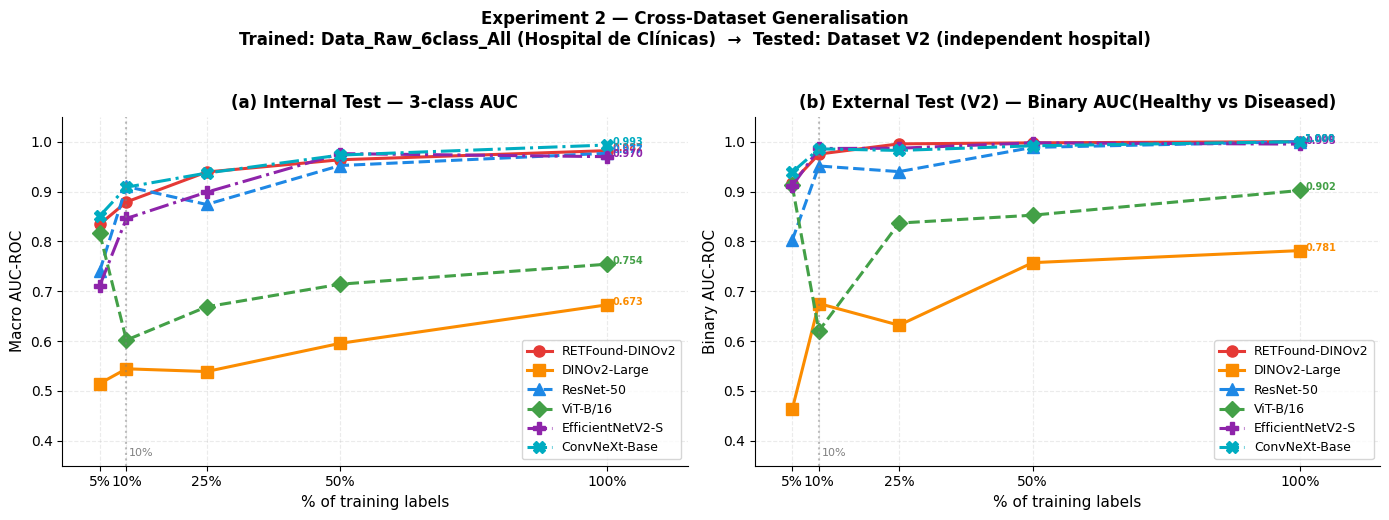

Figure 1 saved.


In [9]:
MODEL_COLORS={
    'RETFound-DINOv2':'#E53935','DINOv2-Large':'#FB8C00',
    'ResNet-50':'#1E88E5','ViT-B/16':'#43A047',
    'EfficientNetV2-S':'#8E24AA','ConvNeXt-Base':'#00ACC1'
}
MODEL_MARKERS={'RETFound-DINOv2':'o','DINOv2-Large':'s','ResNet-50':'^',
               'ViT-B/16':'D','EfficientNetV2-S':'P','ConvNeXt-Base':'X'}
MODEL_LS={'RETFound-DINOv2':'-','DINOv2-Large':'-','ResNet-50':'--',
          'ViT-B/16':'--','EfficientNetV2-S':'-.','ConvNeXt-Base':'-.'}

fig,axes=plt.subplots(1,2,figsize=(14,5))

for ax, (metric, ylabel, title) in zip(axes,[
    ('Int_AUC','Macro AUC-ROC','(a) Internal Test — 3-class AUC'),
    ('Ext_AUC','Binary AUC-ROC','(b) External Test (V2) — Binary AUC(Healthy vs Diseased)')]):
    for mname in MODEL_REGISTRY:
        sub=results_df[results_df['Model']==mname].sort_values('Fraction')
        if len(sub)==0: continue
        ax.plot(sub['Pct'],sub[metric],
                color=MODEL_COLORS[mname],marker=MODEL_MARKERS[mname],
                linestyle=MODEL_LS[mname],linewidth=2.2,markersize=8,label=mname)
        last=sub[sub['Pct']==100]
        if len(last):
            ax.annotate(f"{last[metric].values[0]:.3f}",
                        xy=(100,last[metric].values[0]),xytext=(4,0),
                        textcoords='offset points',fontsize=7,
                        color=MODEL_COLORS[mname],fontweight='bold')
    ax.axvline(x=10,color='gray',linestyle=':',alpha=0.5)
    ax.text(10.5,0.37,'10%',fontsize=8,color='gray')
    ax.set_xlabel('% of training labels',fontsize=11)
    ax.set_ylabel(ylabel,fontsize=11)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xticks([5,10,25,50,100])
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
    ax.set_xlim(-2,115); ax.set_ylim(0.35,1.05)
    ax.legend(fontsize=9,loc='lower right')
    ax.grid(True,alpha=0.25,linestyle='--')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 2 — Cross-Dataset Generalisation\n'
             'Trained: Data_Raw_6class_All (Hospital de Clínicas)  →  Tested: Dataset V2 (independent hospital)',
             fontsize=12,fontweight='bold',y=1.03)
plt.tight_layout()
plt.savefig('/kaggle/working/e2_fig1_auc_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Cell 10 — Figure 2: Sensitivity & Specificity Curves

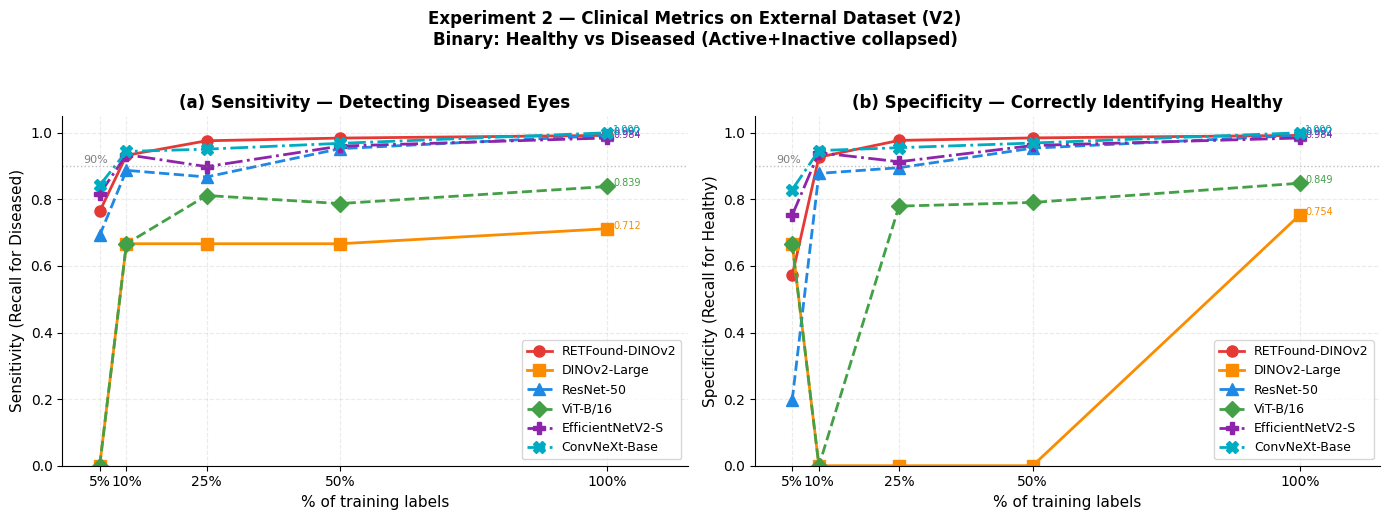

In [10]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

for ax,(metric,ylabel,title) in zip(axes,[
    ('Ext_Sens','Sensitivity (Recall for Diseased)','(a) Sensitivity — Detecting Diseased Eyes'),
    ('Ext_Spec','Specificity (Recall for Healthy)', '(b) Specificity — Correctly Identifying Healthy')]):
    for mname in MODEL_REGISTRY:
        sub=results_df[results_df['Model']==mname].sort_values('Fraction')
        if len(sub)==0: continue
        ax.plot(sub['Pct'],sub[metric],
                color=MODEL_COLORS[mname],marker=MODEL_MARKERS[mname],
                linestyle=MODEL_LS[mname],linewidth=2,markersize=8,label=mname)
        last=sub[sub['Pct']==100]
        if len(last):
            ax.annotate(f"{last[metric].values[0]:.3f}",
                        xy=(100,last[metric].values[0]),xytext=(4,0),
                        textcoords='offset points',fontsize=7,
                        color=MODEL_COLORS[mname])
    ax.set_xlabel('% of training labels',fontsize=11)
    ax.set_ylabel(ylabel,fontsize=11)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xticks([5,10,25,50,100])
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
    ax.set_xlim(-2,115); ax.set_ylim(0.0,1.05)
    ax.axhline(y=0.9,color='gray',linestyle=':',alpha=0.5,linewidth=1)
    ax.text(2,0.91,'90%',fontsize=8,color='gray')
    ax.legend(fontsize=9,loc='lower right')
    ax.grid(True,alpha=0.25,linestyle='--')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 2 — Clinical Metrics on External Dataset (V2)\n'
             'Binary: Healthy vs Diseased (Active+Inactive collapsed)', fontsize=12,fontweight='bold',y=1.03)
plt.tight_layout()
plt.savefig('/kaggle/working/e2_fig2_sens_spec.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 11 — Figure 3: ROC Curves @ 100% Labels

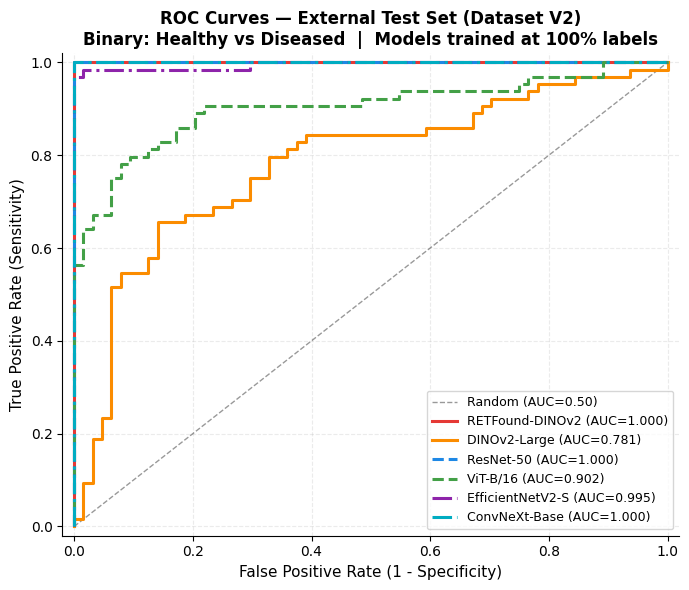

Figure 3 saved.


In [11]:
fig,ax=plt.subplots(figsize=(7,6))
ax.plot([0,1],[0,1],'k--',alpha=0.4,linewidth=1,label='Random (AUC=0.50)')

for mname,data in best_models.items():
    ext_probs=data['ext_probs']
    ext_labels=data['ext_labels']
    disease_prob=ext_probs[:,1]   # P(Diseased)
    try:
        fpr,tpr,_=roc_curve(ext_labels,disease_prob)
        auc_val=roc_auc_score(ext_labels,disease_prob)
        ax.plot(fpr,tpr,color=MODEL_COLORS[mname],
                linewidth=2.2,linestyle=MODEL_LS[mname],
                label=f'{mname} (AUC={auc_val:.3f})')
    except Exception as e:
        print(f'[WARN] {mname} ROC failed: {e}')

ax.set_xlabel('False Positive Rate (1 - Specificity)',fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)',fontsize=11)
ax.set_title('ROC Curves — External Test Set (Dataset V2)\n'
             'Binary: Healthy vs Diseased  |  Models trained at 100% labels',
             fontweight='bold')
ax.legend(fontsize=9,loc='lower right')
ax.grid(True,alpha=0.25,linestyle='--')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/e2_fig3_roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## Cell 12 — Figure 4: External AUC Heatmap

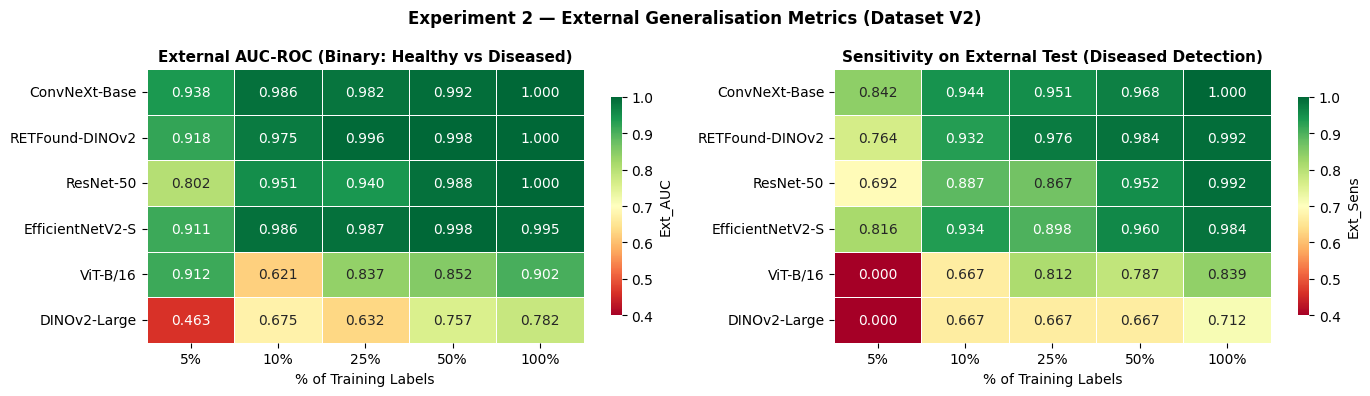


── External AUC-ROC ──
Pct                 5      10     25     50     100
Model                                              
ConvNeXt-Base     0.938  0.986  0.982  0.992  1.000
DINOv2-Large      0.463  0.675  0.632  0.757  0.782
EfficientNetV2-S  0.911  0.986  0.987  0.998  0.995
RETFound-DINOv2   0.918  0.975  0.996  0.998  1.000
ResNet-50         0.802  0.951  0.940  0.988  1.000
ViT-B/16          0.912  0.621  0.837  0.852  0.902

── External Sensitivity ──
Pct                 5      10     25     50     100
Model                                              
ConvNeXt-Base     0.842  0.944  0.951  0.968  1.000
DINOv2-Large      0.000  0.667  0.667  0.667  0.712
EfficientNetV2-S  0.816  0.934  0.898  0.960  0.984
RETFound-DINOv2   0.764  0.932  0.976  0.984  0.992
ResNet-50         0.692  0.887  0.867  0.952  0.992
ViT-B/16          0.000  0.667  0.812  0.787  0.839

── External Specificity ──
Pct                 5      10     25     50     100
Model                               

In [12]:
fig,axes=plt.subplots(1,2,figsize=(14,4))

for ax,(metric,title) in zip(axes,[
    ('Ext_AUC','External AUC-ROC (Binary: Healthy vs Diseased)'),
    ('Ext_Sens','Sensitivity on External Test (Diseased Detection)')]):
    pivot=results_df.pivot_table(index='Model',columns='Pct',values=metric).round(3)
    pivot.columns=[f'{c}%' for c in pivot.columns]
    pivot=pivot.sort_values('100%',ascending=False)
    sns.heatmap(pivot,annot=True,fmt='.3f',cmap='RdYlGn',
                vmin=0.40,vmax=1.00,linewidths=0.6,ax=ax,
                cbar_kws={'label':metric,'shrink':0.8})
    ax.set_title(title,fontsize=11,fontweight='bold')
    ax.set_xlabel('% of Training Labels'); ax.set_ylabel('')

plt.suptitle('Experiment 2 — External Generalisation Metrics (Dataset V2)', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/e2_fig4_ext_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

# Print full results table
print('\n── External AUC-ROC ──')
print(results_df.pivot_table(index='Model',columns='Pct',values='Ext_AUC').round(3).to_string())
print('\n── External Sensitivity ──')
print(results_df.pivot_table(index='Model',columns='Pct',values='Ext_Sens').round(3).to_string())
print('\n── External Specificity ──')
print(results_df.pivot_table(index='Model',columns='Pct',values='Ext_Spec').round(3).to_string())

## Cell 13 — Figure 5: Confusion Matrices @ 100% Labels (External V2)

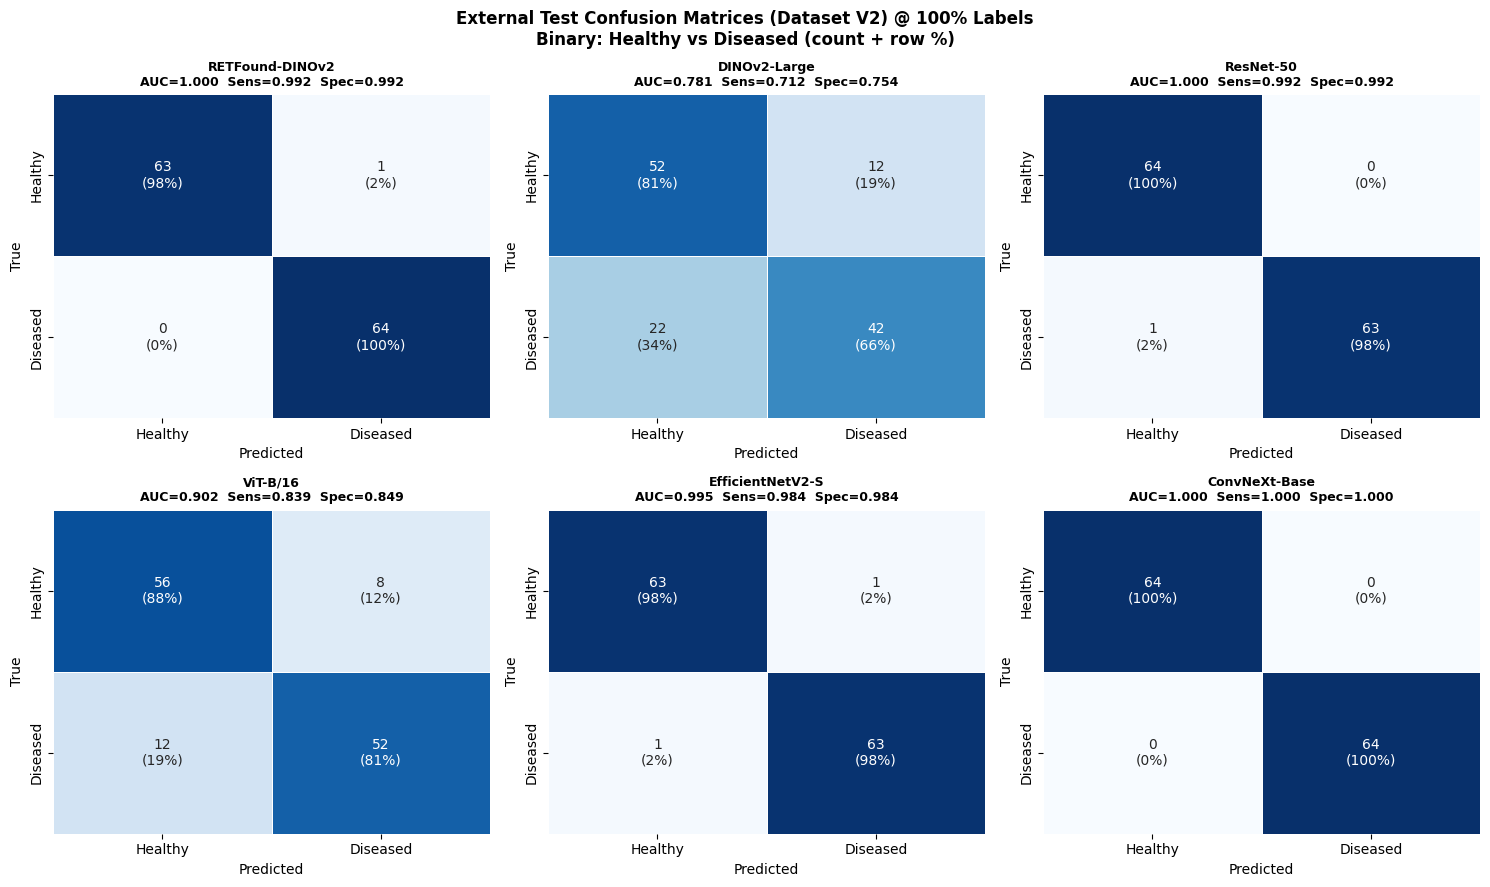

In [13]:
n_m=len(best_models)
fig,axes=plt.subplots(2,3,figsize=(15,9))
axes=axes.flatten()

for ax,(mname,data) in zip(axes,best_models.items()):
    ext_preds=data['ext_preds']; ext_labels=data['ext_labels']
    cm=confusion_matrix(ext_labels,ext_preds)
    cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True)
    annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm,annot=annot,fmt='',cmap='Blues',
                xticklabels=CLASS_NAMES_2,yticklabels=CLASS_NAMES_2,
                linewidths=0.5,ax=ax,cbar=False,vmin=0,vmax=1)
    r=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)].iloc[0]
    ax.set_title(f'{mname}\nAUC={r.Ext_AUC:.3f}  Sens={r.Ext_Sens:.3f}  Spec={r.Ext_Spec:.3f}',
                 fontweight='bold',fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

for ax in axes[n_m:]: ax.set_visible(False)

plt.suptitle('External Test Confusion Matrices (Dataset V2) @ 100% Labels\n'
             'Binary: Healthy vs Diseased (count + row %)',
             fontweight='bold',fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/e2_fig5_ext_confusion.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 14 — Generalisation Gap Analysis

── Generalisation Gap Analysis ──
  (Internal 3-class AUC) - (External binary AUC) at each fraction
  Smaller gap = model generalises better to unseen hospital data

                     5%    10%    25%    50%   100%  Mean Gap
Model                                                        
ViT-B/16         -0.096 -0.019 -0.168 -0.138 -0.148    -0.114
EfficientNetV2-S -0.200 -0.140 -0.088 -0.022 -0.025    -0.095
DINOv2-Large      0.052 -0.131 -0.093 -0.162 -0.109    -0.089
RETFound-DINOv2  -0.084 -0.096 -0.056 -0.034 -0.018    -0.058
ConvNeXt-Base    -0.088 -0.077 -0.045 -0.019 -0.007    -0.047
ResNet-50        -0.062 -0.041 -0.066 -0.036 -0.023    -0.046


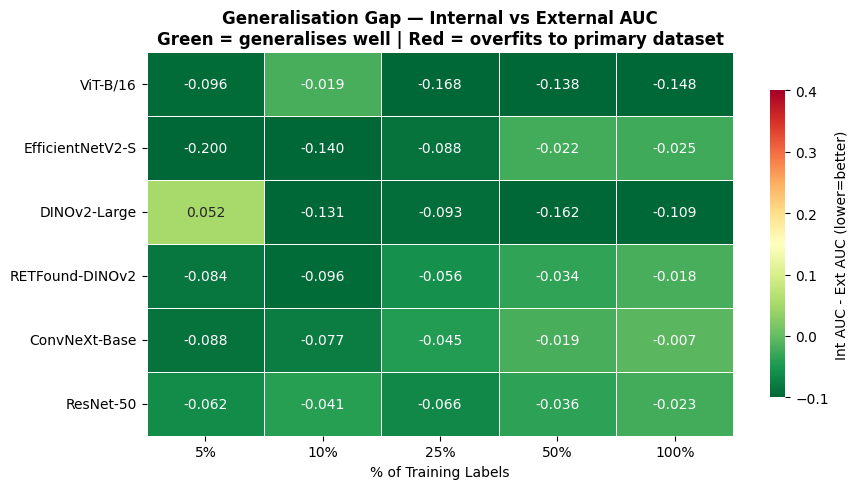

In [14]:
# Generalisation gap = Internal AUC - External AUC
# Smaller gap = better generalisation
print('── Generalisation Gap Analysis ──')
print('  (Internal 3-class AUC) - (External binary AUC) at each fraction')
print('  Smaller gap = model generalises better to unseen hospital data')
print()

gap_rows=[]
for mname in MODEL_REGISTRY:
    for frac in LABEL_FRACS:
        sub=results_df[(results_df['Model']==mname)&(results_df['Fraction']==frac)]
        if len(sub)==0: continue
        r=sub.iloc[0]
        gap=r.Int_AUC-r.Ext_AUC
        gap_rows.append({'Model':mname,'Pct':int(frac*100),
                          'Int_AUC':r.Int_AUC,'Ext_AUC':r.Ext_AUC,'Gap':round(gap,4)})

gap_df=pd.DataFrame(gap_rows)

# Pivot gap by model × fraction
gap_pivot=gap_df.pivot_table(index='Model',columns='Pct',values='Gap').round(3)
gap_pivot.columns=[f'{c}%' for c in gap_pivot.columns]
gap_pivot['Mean Gap']=gap_pivot.mean(axis=1).round(3)
gap_pivot=gap_pivot.sort_values('Mean Gap')

print(gap_pivot.to_string())

# Plot
fig,ax=plt.subplots(figsize=(9,5))
sns.heatmap(gap_pivot.drop('Mean Gap',axis=1),annot=True,fmt='.3f',
            cmap='RdYlGn_r',  # Red=large gap (bad), Green=small gap (good)
            vmin=-0.1,vmax=0.4,linewidths=0.6,ax=ax,
            cbar_kws={'label':'Int AUC - Ext AUC (lower=better)','shrink':0.8})
ax.set_title('Generalisation Gap — Internal vs External AUC\n'
             'Green = generalises well | Red = overfits to primary dataset', fontweight='bold')
ax.set_xlabel('% of Training Labels'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/kaggle/working/e2_fig6_gen_gap.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 15 — Final Summary

In [15]:
print('='*68)
print('  EXPERIMENT 2 — CROSS-DATASET GENERALISATION SUMMARY')
print('  Primary: Data_Raw_6class_All → External: Dataset V2')
print('  Evaluation: Binary (Healthy vs Diseased)')
print('='*68)

# Best external AUC overall
best=results_df.loc[results_df['Ext_AUC'].idxmax()]
print(f'\n Best external AUC : {best.Model} @ {best.Pct}% labels')
print(f'   Ext_AUC={best.Ext_AUC:.4f}  Sens={best.Ext_Sens:.4f}  Spec={best.Ext_Spec:.4f}')

print('\n── Best model per fraction (External AUC) ──')
for pct in [5,10,25,50,100]:
    sub=results_df[results_df['Pct']==pct]
    if len(sub):
        row=sub.loc[sub['Ext_AUC'].idxmax()]
        print(f'  {pct:3d}%  {row.Model:22s}  ExtAUC={row.Ext_AUC:.4f}  '
              f'Sens={row.Ext_Sens:.4f}  Spec={row.Ext_Spec:.4f}')

print('\n── Full table @ 100% labels ──')
at100=results_df[results_df['Pct']==100].sort_values('Ext_AUC',ascending=False)
print(at100[['Model','Int_AUC','Ext_AUC','Ext_Sens','Ext_Spec','Ext_AP']].to_string(index=False))

print('\n── Generalisation gap @ 100% (Int_AUC - Ext_AUC) ──')
for mname in MODEL_REGISTRY:
    r=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)]
    if len(r):
        r=r.iloc[0]; gap=r.Int_AUC-r.Ext_AUC
        print(f'  {mname:22s}: Δ={gap:+.3f}  (Int={r.Int_AUC:.3f} → Ext={r.Ext_AUC:.3f})')

print('\n── Saved figures ──')
for f in sorted(Path('/kaggle/working').glob('e2_fig*.png')):
    print(f'  {f.name}')
print('  experiment2_results.csv')

  EXPERIMENT 2 — CROSS-DATASET GENERALISATION SUMMARY
  Primary: Data_Raw_6class_All → External: Dataset V2
  Evaluation: Binary (Healthy vs Diseased)

 Best external AUC : RETFound-DINOv2 @ 100% labels
   Ext_AUC=1.0000  Sens=0.9922  Spec=0.9921

── Best model per fraction (External AUC) ──
    5%  ConvNeXt-Base           ExtAUC=0.9385  Sens=0.8421  Spec=0.8293
   10%  EfficientNetV2-S        ExtAUC=0.9863  Sens=0.9344  Spec=0.9403
   25%  RETFound-DINOv2         ExtAUC=0.9956  Sens=0.9760  Spec=0.9771
   50%  RETFound-DINOv2         ExtAUC=0.9976  Sens=0.9841  Spec=0.9846
  100%  RETFound-DINOv2         ExtAUC=1.0000  Sens=0.9922  Spec=0.9921

── Full table @ 100% labels ──
           Model  Int_AUC  Ext_AUC  Ext_Sens  Ext_Spec  Ext_AP
 RETFound-DINOv2   0.9820   1.0000    0.9922    0.9921  1.0000
       ResNet-50   0.9767   1.0000    0.9921    0.9922  1.0000
   ConvNeXt-Base   0.9933   1.0000    1.0000    1.0000  1.0000
EfficientNetV2-S   0.9699   0.9951    0.9844    0.9844  0.9962
